# Clean-Label Poisoning — Transfer Learning (Attack 2 + Defense)
<!-- 
Frozen ImageNet ResNet-18, retrained linear head, CIFAR-10.
Attack: one poison image, correctly labelled. Defense: two layers. -->

In [1]:

import os, json, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

print("torch", torch.__version__, "| CUDA", torch.cuda.is_available())

torch 2.10.0+cu128 | CUDA True


## Config

In [2]:

SEED = 406

TRAIN_SAMPLES_PER_CLASS = 200      # N_tr = 2000
TEST_SAMPLES_PER_CLASS  = 1000
EPOCHS      = 100
BATCH_SIZE  = 128
HEAD_LR     = 0.01
WEIGHT_DECAY = 0.0
FEATURE_BATCH_SIZE = 256
NUM_WORKERS = 2

# attack
TARGET_CLASS = 0        # airplane
BASE_CLASS   = 6        # frog
BASE_RANK    = 0
NUM_TRIALS   = 50
ATTACK_STEPS = 3000
ATTACK_LR    = 0.01
ATTACK_BETA  = 0.1
ATTACK_EPSILON = 0.06
RUN_EPSILON_SWEEP = True
EPSILON_SWEEP  = [2/255, 0.03, 0.06, 0.12]
NUM_TRIALS_EPS = 15

# defense
DEFENSE_K = 10
DEFENSE_VAL_PER_CLASS = 100
DEFENSE_MAX_CLEAN_LOSS = 0.05
DEF_FLIP_BUDGETS = [0.01, 0.02, 0.05, 0.10]
DEF_FLIP_RULES   = ["random", "low_confidence"]
DEFENSE_EVAL_TRIALS = NUM_TRIALS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR   = Path("/kaggle/working/data")   if Path("/kaggle/working").is_dir() else Path("./data")
OUTPUT_DIR = Path("/kaggle/working/artifacts") if Path("/kaggle/working").is_dir() else Path("./artifacts")
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "poisons").mkdir(parents=True, exist_ok=True)
print("device:", DEVICE)

device: cuda


## Reproducibility

## Data and model

In [3]:

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

In [4]:

class ImageSet(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = images; self.labels = labels.long()
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i): return self.images[i], int(self.labels[i])


def load_cifar10(root, train):
    from torchvision.datasets import CIFAR10
    from torchvision.transforms import ToTensor
    return CIFAR10(root=str(root), train=train, transform=ToTensor(), download=True)


def class_indices(ds, c):
    return [i for i, y in enumerate(ds.targets) if int(y) == c]


def shuffled_class_indices(ds, c, seed):
    order = class_indices(ds, c)[:]
    random.Random(seed).shuffle(order)
    return order


def balanced_subset(ds, per_class, seed, skip=0, n_classes=10):
    idx = []
    for c in range(n_classes):
        chunk = shuffled_class_indices(ds, c, seed)[skip:skip + per_class]
        assert len(chunk) == per_class, f"class {c}: not enough samples"
        idx += chunk
    imgs, lbls = zip(*(ds[i] for i in idx))
    return ImageSet(torch.stack(imgs), torch.tensor(lbls))


def sample_records(ds, c, count, seed, exclude=None):
    order = shuffled_class_indices(ds, c, seed)
    if exclude:
        order = [i for i in order if i not in exclude]
    return [{"index": i, "image": ds[i][0]} for i in order[:count]]


class Extractor(nn.Module):
    """Upsample 32->224, ImageNet-normalize, then the frozen ResNet body."""
    def __init__(self, body, size=224):
        super().__init__()
        self.body = body; self.size = size
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def forward(self, x):
        x = F.interpolate(x, size=(self.size, self.size), mode="bilinear", align_corners=False)
        return self.body((x - self.mean) / self.std)


def build_extractor():
    from torchvision.models import resnet18, ResNet18_Weights
    net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)   # pinned checkpoint
    net.fc = nn.Identity()
    ex = Extractor(net).to(DEVICE).eval()
    ex.requires_grad_(False)
    return ex


@torch.no_grad()
def extract_features(ex, dataset, workers=0):
    loader = DataLoader(dataset, batch_size=FEATURE_BATCH_SIZE, shuffle=False, num_workers=workers)
    feats, lbls = [], []
    for x, y in loader:
        feats.append(ex(x.to(DEVICE)).flatten(1).cpu())
        lbls.append(torch.as_tensor(y).long())
    return torch.cat(feats), torch.cat(lbls)


def fit_head(X, y, seed, epochs=EPOCHS):
    """Adam, no weight decay, to near-zero training loss: the attack needs the
    fit to be underdetermined, and weight decay would smooth the poison away."""
    seed_everything(seed)
    gen = torch.Generator().manual_seed(seed)
    loader = DataLoader(TensorDataset(X, y), batch_size=BATCH_SIZE, shuffle=True, generator=gen)
    head = nn.Linear(X.shape[1], 10).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    lossf = nn.CrossEntropyLoss()
    for _ in range(epochs):
        head.train()
        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            lossf(head(bx), by).backward()
            opt.step()
    return head


@torch.no_grad()
def predict(head, X, bs=1024):
    head.eval()
    return torch.cat([head(X[i:i+bs].to(DEVICE)).argmax(1).cpu() for i in range(0, len(X), bs)])


@torch.no_grad()
def predict_one(head, feat):
    head.eval()
    p = torch.softmax(head(feat.to(DEVICE).unsqueeze(0)), dim=1)[0].cpu()
    return int(p.argmax()), p.tolist()


def accuracy(head, X, y):
    return float((predict(head, X) == y).float().mean())

## Load data, extract frozen features

In [5]:

train_source = load_cifar10(DATA_DIR, True)
test_source  = load_cifar10(DATA_DIR, False)
class_names  = list(train_source.classes)

extractor  = build_extractor()
clean_train = balanced_subset(train_source, TRAIN_SAMPLES_PER_CLASS, SEED)
clean_test  = balanced_subset(test_source,  TEST_SAMPLES_PER_CLASS,  SEED)

t0 = time.time()
X_train, y_train = extract_features(extractor, clean_train, NUM_WORKERS)
X_test,  y_test  = extract_features(extractor, clean_test,  NUM_WORKERS)
feature_dim = X_train.shape[1]
print(f"train {len(X_train)}  test {len(X_test)}  dim {feature_dim}  ({time.time()-t0:.0f}s)")

assert len(X_train) <= feature_dim * 10, "fit is over-determined; the attack will fail"

100%|██████████| 170M/170M [24:15<00:00, 117kB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


train 2000  test 10000  dim 512  (12s)


## Clean baseline

In [6]:

clean_head = fit_head(X_train, y_train, SEED)
baseline_acc = accuracy(clean_head, X_test, y_test)
baseline_f1  = float(f1_score(y_test.numpy(), predict(clean_head, X_test).numpy(), average="macro"))
print(f"clean accuracy {baseline_acc:.4f}  macro-F1 {baseline_f1:.4f}")

clean accuracy 0.8132  macro-F1 0.8128


## Attack: feature collision

In [7]:

def feature_distance(a, b):
    a, b = a.flatten(1), b.flatten(1)
    return (a - b).pow(2).sum(1) / a.shape[1]


def project_linf(x, base, eps):
    return torch.max(torch.min(x, (base + eps).clamp(0, 1)), (base - eps).clamp(0, 1))


def craft(ex, bases, targets, steps, lr, beta, eps, log_every=0):
    """p = argmin ||f(p)-f(target)||^2 + beta*||p-base||^2, projected to an
    eps-ball around the base. Pairs are optimised jointly: the extractor is in
    eval() so BatchNorm uses fixed stats and batch elements do not interact."""
    ex.eval()
    with torch.no_grad():
        tf = ex(targets).detach()
    p = bases.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([p], lr=lr)
    hist = []
    for i in range(steps):
        opt.zero_grad(set_to_none=True)
        floss = feature_distance(ex(p), tf).mean()
        vloss = (p - bases).pow(2).mean()
        (floss + beta * vloss).backward()
        opt.step()
        with torch.no_grad():
            p.copy_(project_linf(p, bases, eps))
        if log_every and ((i + 1) % log_every == 0 or i == 0):
            hist.append({"step": i + 1, "feature_loss": float(floss.detach()),
                         "linf": float((p.detach() - bases).abs().max())})
    with torch.no_grad():
        final = feature_distance(ex(p), tf).cpu().tolist()
    return p.detach(), hist, final

In [8]:

base0   = sample_records(test_source, BASE_CLASS, BASE_RANK + 1, SEED)[BASE_RANK]
targets = sample_records(test_source, TARGET_CLASS, NUM_TRIALS, SEED)

bases_batch   = base0["image"].unsqueeze(0).repeat(NUM_TRIALS, 1, 1, 1).to(DEVICE)
targets_batch = torch.stack([t["image"] for t in targets]).to(DEVICE)

seed_everything(SEED)
t0 = time.time()
poisons, hist, final_dist = craft(extractor, bases_batch, targets_batch,
                                  ATTACK_STEPS, ATTACK_LR, ATTACK_BETA, ATTACK_EPSILON,
                                  log_every=ATTACK_STEPS // 10)
print(f"crafted {NUM_TRIALS} poisons in {time.time()-t0:.0f}s")

poison_feats = extract_features(extractor, ImageSet(poisons.cpu(), torch.full((NUM_TRIALS,), BASE_CLASS)))[0]
target_feats = extract_features(extractor, ImageSet(targets_batch.cpu(), torch.full((NUM_TRIALS,), TARGET_CLASS)))[0]

crafted 50 poisons in 477s


In [9]:

results = []
for k in range(NUM_TRIALS):
    seed = SEED + k
    Xp = torch.cat([X_train, poison_feats[k].unsqueeze(0)])
    yp = torch.cat([y_train, torch.tensor([BASE_CLASS])])

    h_clean = fit_head(X_train, y_train, seed)
    h_pois  = fit_head(Xp, yp, seed)

    c_pred, _       = predict_one(h_clean, target_feats[k])
    p_pred, p_probs = predict_one(h_pois,  target_feats[k])
    poison_pred, _  = predict_one(h_pois,  poison_feats[k])

    a_clean, a_pois = accuracy(h_clean, X_test, y_test), accuracy(h_pois, X_test, y_test)
    results.append({
        "trial": k, "target_index": targets[k]["index"],
        "clean_correct": c_pred == TARGET_CLASS,
        "success": bool(c_pred == TARGET_CLASS and p_pred == BASE_CLASS),
        "clean_prediction": c_pred, "poisoned_prediction": p_pred,
        "confidence_in_base": p_probs[BASE_CLASS],
        "poison_learned_as_base": bool(poison_pred == BASE_CLASS),
        "feature_distance": final_dist[k],
        "clean_accuracy": a_clean, "poisoned_accuracy": a_pois,
        "accuracy_delta": a_pois - a_clean,
        "linf": float((poisons[k] - bases_batch[k]).abs().max().cpu()),
    })
    print(f"trial {k:02d}  clean={class_names[c_pred]:>10s}  poisoned={class_names[p_pred]:>10s}  "
          f"success={results[-1]['success']}  delta={results[-1]['accuracy_delta']:+.4f}")

trial 00  clean=  airplane  poisoned=      frog  success=True  delta=-0.0020
trial 01  clean=  airplane  poisoned=      frog  success=True  delta=-0.0024
trial 02  clean=  airplane  poisoned=      frog  success=True  delta=-0.0003
trial 03  clean=  airplane  poisoned=      frog  success=True  delta=+0.0019
trial 04  clean=automobile  poisoned=      frog  success=False  delta=+0.0022
trial 05  clean=  airplane  poisoned=      frog  success=True  delta=-0.0020
trial 06  clean=      ship  poisoned=      frog  success=False  delta=+0.0021
trial 07  clean=  airplane  poisoned=      frog  success=True  delta=-0.0006
trial 08  clean=  airplane  poisoned=      frog  success=True  delta=-0.0026
trial 09  clean=  airplane  poisoned=      frog  success=True  delta=-0.0039
trial 10  clean=  airplane  poisoned=      frog  success=True  delta=-0.0011
trial 11  clean=  airplane  poisoned=      frog  success=True  delta=-0.0033
trial 12  clean=  airplane  poisoned=      frog  success=True  delta=-0.00

## Results

In [10]:

eligible  = [r for r in results if r["clean_correct"]]
successes = [r for r in results if r["success"]]
mean = lambda k, rows=results: sum(r[k] for r in rows) / len(rows) if rows else float("nan")

summary = {
    "trials": NUM_TRIALS, "eligible": len(eligible), "successes": len(successes),
    "raw_success_rate": len(successes) / NUM_TRIALS,
    "conditional_success_rate": len(successes) / len(eligible) if eligible else float("nan"),
    "mean_accuracy_delta": mean("accuracy_delta"),
    "mean_confidence_on_success": mean("confidence_in_base", successes),
    "poison_learned_as_base_rate": mean("poison_learned_as_base"),
    "clean_baseline_accuracy": baseline_acc,
    "config": {"seed": SEED, "train_per_class": TRAIN_SAMPLES_PER_CLASS, "epochs": EPOCHS,
               "head_lr": HEAD_LR, "weight_decay": WEIGHT_DECAY, "steps": ATTACK_STEPS,
               "beta": ATTACK_BETA, "epsilon": ATTACK_EPSILON,
               "target": class_names[TARGET_CLASS], "base": class_names[BASE_CLASS]},
}
print(f"raw success         {summary['raw_success_rate']:.1%}")
print(f"conditional success {summary['conditional_success_rate']:.1%} "
      f"({len(successes)}/{len(eligible)})   [targets the clean model got right]")
print(f"mean accuracy delta {summary['mean_accuracy_delta']:+.4f}")
print(f"mean confidence     {summary['mean_confidence_on_success']:.3f}")

json.dump({"summary": summary, "trials": results}, open(OUTPUT_DIR / "attack_results.json", "w"), indent=2)

raw success         86.0%
conditional success 100.0% (43/43)   [targets the clean model got right]
mean accuracy delta -0.0008
mean confidence     0.959


## Plots

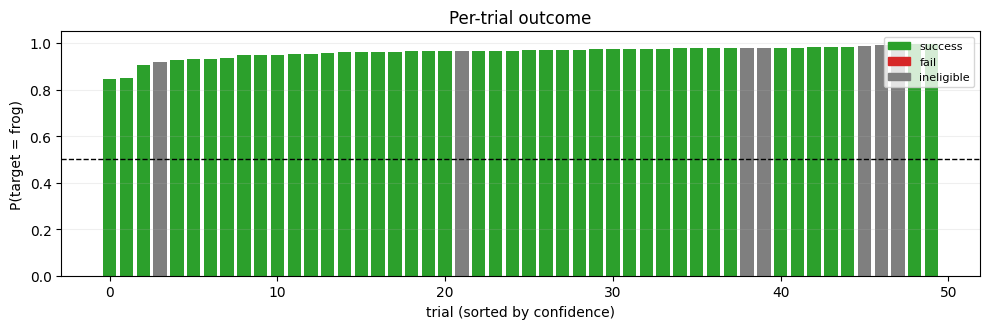

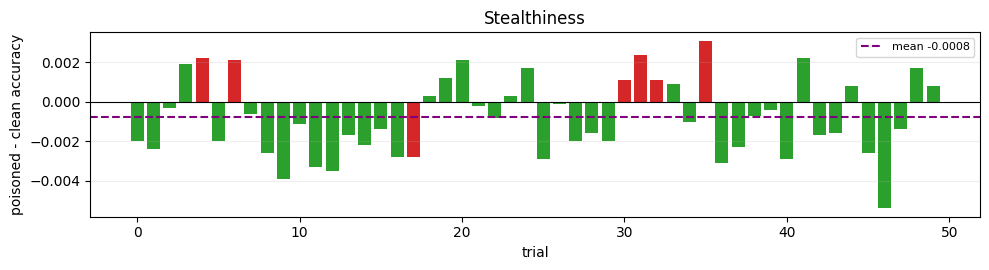

In [11]:

ordered = sorted(results, key=lambda r: r["confidence_in_base"])
colors = ["tab:gray" if not r["clean_correct"] else ("tab:green" if r["success"] else "tab:red")
          for r in ordered]

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(range(len(ordered)), [r["confidence_in_base"] for r in ordered], color=colors)
ax.axhline(0.5, color="black", linestyle="--", lw=1)
ax.set(xlabel="trial (sorted by confidence)", ylabel=f"P(target = {class_names[BASE_CLASS]})",
       ylim=(0, 1.05), title="Per-trial outcome")
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=c, label=l) for c, l in
                   [("tab:green","success"),("tab:red","fail"),("tab:gray","ineligible")]], fontsize=8)
ax.grid(alpha=0.2, axis="y")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/per_trial.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.bar([r["trial"] for r in results], [r["accuracy_delta"] for r in results],
       color=["tab:green" if r["success"] else "tab:red" for r in results])
ax.axhline(0, color="black", lw=0.8)
ax.axhline(summary["mean_accuracy_delta"], color="purple", linestyle="--",
           label=f"mean {summary['mean_accuracy_delta']:+.4f}")
ax.set(xlabel="trial", ylabel="poisoned - clean accuracy", title="Stealthiness")
ax.legend(fontsize=8); ax.grid(alpha=0.2, axis="y")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/accuracy_delta.png", dpi=150); plt.show()

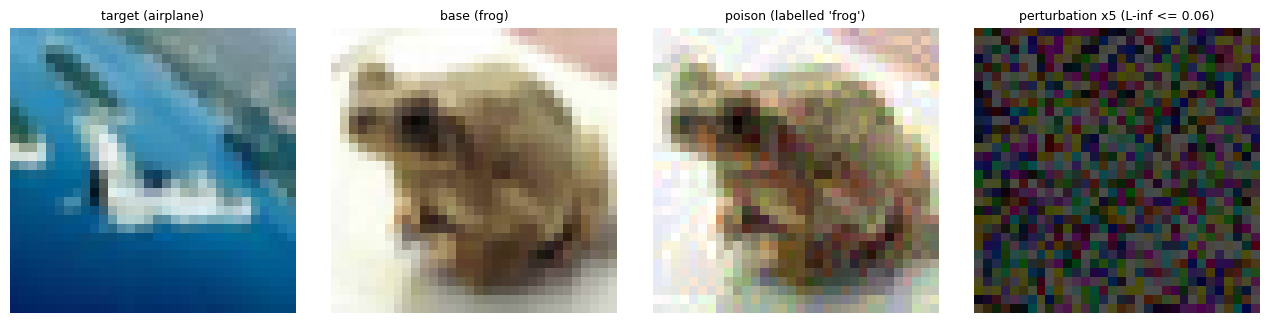

In [12]:

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
panels = [(targets[0]["image"], f"target ({class_names[TARGET_CLASS]})"),
          (base0["image"], f"base ({class_names[BASE_CLASS]})"),
          (poisons[0].cpu(), f"poison (labelled {class_names[BASE_CLASS]!r})"),
          (((poisons[0].cpu() - base0["image"]).abs() * 5).clamp(0, 1),
           f"perturbation x5 (L-inf <= {ATTACK_EPSILON})")]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy()); ax.set_title(title, fontsize=9); ax.axis("off")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/showcase.png", dpi=150); plt.show()

for i in range(min(10, NUM_TRIALS)):
    to_pil_image(poisons[i].cpu().clamp(0, 1)).save(OUTPUT_DIR / f"poisons/poison_{i:02d}.png")
to_pil_image(base0["image"]).save(OUTPUT_DIR / "poisons/base.png")

## Figures

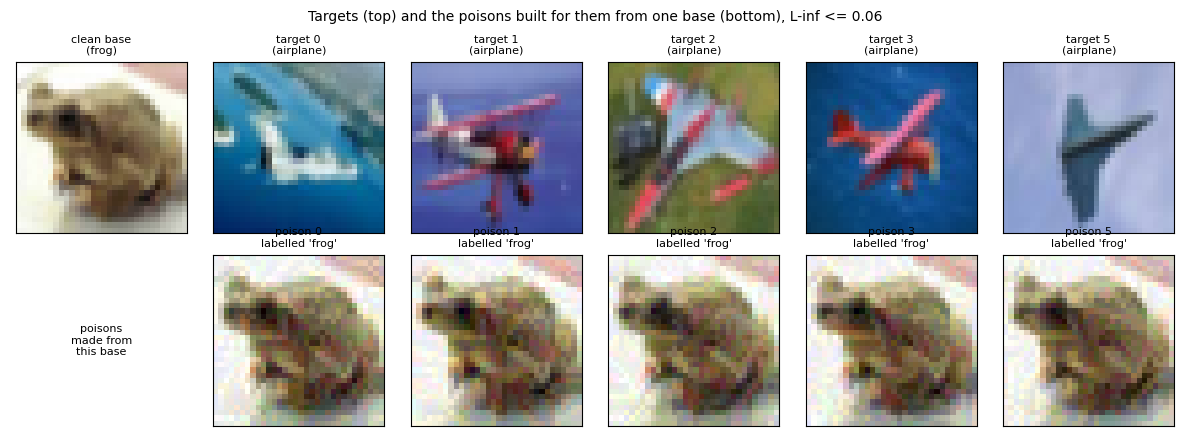

In [13]:
N_SHOW = 5
show = [r["trial"] for r in results if r["success"]][:N_SHOW]
if len(show) < N_SHOW:
    show = list(range(N_SHOW))

fig, axes = plt.subplots(2, N_SHOW + 1, figsize=(2.0 * (N_SHOW + 1), 4.4))

axes[0, 0].imshow(base0["image"].permute(1, 2, 0).numpy())
axes[0, 0].set_title(f"clean base\n({class_names[BASE_CLASS]})", fontsize=8)
axes[1, 0].axis("off")
axes[1, 0].text(0.5, 0.5, "poisons\nmade from\nthis base", ha="center", va="center", fontsize=8)

for col, k in enumerate(show, start=1):
    axes[0, col].imshow(targets[k]["image"].permute(1, 2, 0).numpy())
    axes[0, col].set_title(f"target {k}\n({class_names[TARGET_CLASS]})", fontsize=8)
    axes[1, col].imshow(poisons[k].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, col].set_title(f"poison {k}\nlabelled {class_names[BASE_CLASS]!r}", fontsize=8)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[1, 0].axis("off")
fig.suptitle(f"Targets (top) and the poisons built for them from one base "
             f"(bottom), L-inf <= {ATTACK_EPSILON}", fontsize=10)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots/poison_grid.png", dpi=150); plt.show()

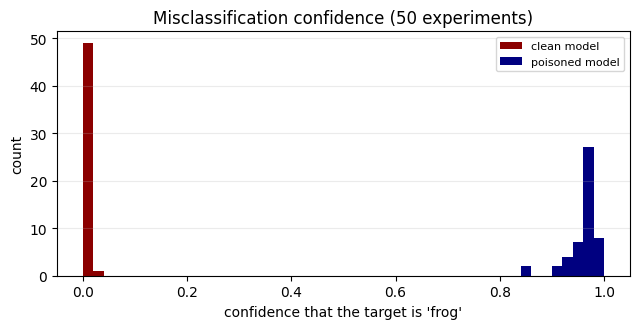

clean model    mean 0.0007   max 0.0307
poisoned model mean 0.9606   min 0.8461


In [14]:
clean_conf, poisoned_conf = [], []
for k in range(NUM_TRIALS):
    h_c = fit_head(X_train, y_train, SEED + k)
    _, pc = predict_one(h_c, target_feats[k])
    clean_conf.append(pc[BASE_CLASS])
    poisoned_conf.append(results[k]["confidence_in_base"])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
bins = np.linspace(0, 1, 51)
ax.hist(clean_conf,    bins=bins, color="darkred",  label="clean model")
ax.hist(poisoned_conf, bins=bins, color="navy",     label="poisoned model")
ax.set(xlabel=f"confidence that the target is {class_names[BASE_CLASS]!r}",
       ylabel="count", title=f"Misclassification confidence ({NUM_TRIALS} experiments)")
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/confidence_histogram.png", dpi=150); plt.show()

print(f"clean model    mean {np.mean(clean_conf):.4f}   max {np.max(clean_conf):.4f}")
print(f"poisoned model mean {np.mean(poisoned_conf):.4f}   min {np.min(poisoned_conf):.4f}")

## Epsilon sweep

eps=0.0078  conditional success 0.0% (0/13)
eps=0.0300  conditional success 100.0% (13/13)
eps=0.0600  conditional success 100.0% (13/13)
eps=0.1200  conditional success 100.0% (13/13)


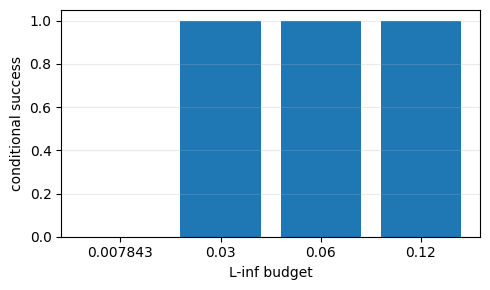

In [15]:
eps_results = []
if RUN_EPSILON_SWEEP:
    for eps in EPSILON_SWEEP:
        p_eps, _, _ = craft(extractor, bases_batch[:NUM_TRIALS_EPS], targets_batch[:NUM_TRIALS_EPS],
                            ATTACK_STEPS, ATTACK_LR, ATTACK_BETA, eps)
        f_eps = extract_features(extractor, ImageSet(p_eps.cpu(),
                                 torch.full((NUM_TRIALS_EPS,), BASE_CLASS)))[0]
        ok = elig = 0
        for k in range(NUM_TRIALS_EPS):
            seed = SEED + k
            h_c = fit_head(X_train, y_train, seed)
            h_p = fit_head(torch.cat([X_train, f_eps[k].unsqueeze(0)]),
                           torch.cat([y_train, torch.tensor([BASE_CLASS])]), seed)
            c_pred, _ = predict_one(h_c, target_feats[k])
            p_pred, _ = predict_one(h_p, target_feats[k])
            if c_pred == TARGET_CLASS:
                elig += 1; ok += (p_pred == BASE_CLASS)
        eps_results.append({"epsilon": eps, "eligible": elig, "successes": ok,
                            "conditional_success_rate": ok / elig if elig else float("nan")})
        print(f"eps={eps:.4f}  conditional success {eps_results[-1]['conditional_success_rate']:.1%} ({ok}/{elig})")

    json.dump(eps_results, open(OUTPUT_DIR / "epsilon_sweep.json", "w"), indent=2)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar([f"{r['epsilon']:.4g}" for r in eps_results],
           [r["conditional_success_rate"] for r in eps_results], color="tab:blue")
    ax.set(xlabel="L-inf budget", ylabel="conditional success", ylim=(0, 1.05))
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/epsilon_sweep.png", dpi=150); plt.show()

# Defense

In [16]:
val_set = balanced_subset(train_source, DEFENSE_VAL_PER_CLASS, SEED, skip=TRAIN_SAMPLES_PER_CLASS)
X_val, y_val = extract_features(extractor, val_set)
print(f"validation {len(y_val)} records, disjoint from train and test")

validation 1000 records, disjoint from train and test


## neighbour check

In [17]:
def knn_disagreement(X, y, k=DEFENSE_K):
    """Fraction of the k nearest neighbours carrying a different label,
    weighted by cosine similarity. Higher = more suspicious."""
    Xn = F.normalize(X.to(DEVICE).float(), dim=1)
    yd = y.to(DEVICE)
    sims = Xn @ Xn.T
    sims.fill_diagonal_(-2.0)
    top = sims.topk(k, dim=1)
    same = (yd[top.indices] == yd[:, None]).float()
    w = top.values.clamp(min=0) + 1e-8
    return (1.0 - (same * w).sum(1) / w.sum(1)).cpu()


clean_scores = knn_disagreement(X_train, y_train).numpy()
print(f"clean records: mean {clean_scores.mean():.3f}  p90 {np.quantile(clean_scores,0.9):.3f}  "
      f"p99 {np.quantile(clean_scores,0.99):.3f}")

clean records: mean 0.359  p90 0.800  p99 1.000


AUC 0.9844
tau=0.925: catches 98.0% of poisons, discards 2.7% of clean records


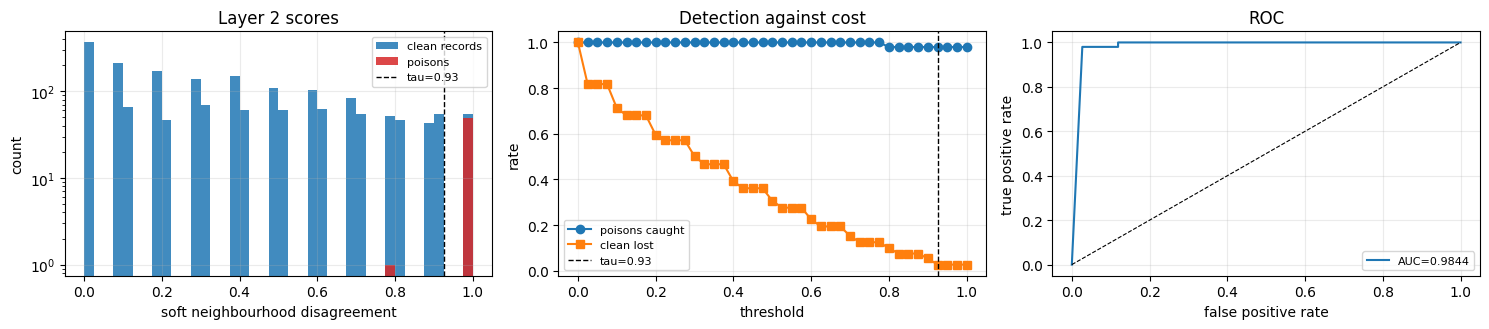

In [18]:
poison_scores = np.array([
    float(knn_disagreement(torch.cat([X_train, poison_feats[k].unsqueeze(0)]),
                           torch.cat([y_train, torch.tensor([BASE_CLASS])]))[-1])
    for k in range(NUM_TRIALS)])

y_true  = np.r_[np.ones(len(poison_scores)), np.zeros(len(clean_scores))]
y_score = np.r_[poison_scores, clean_scores]
auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

grid = np.linspace(0, 1, 41)
sweep = [{"threshold": float(t),
          "detection_rate": float((poison_scores >= t).mean()),
          "clean_rejection_rate": float((clean_scores >= t).mean())} for t in grid]

affordable = [s for s in sweep if s["clean_rejection_rate"] <= DEFENSE_MAX_CLEAN_LOSS]
TAU = min(affordable, key=lambda s: s["threshold"])["threshold"] if affordable else 0.5
op = min(sweep, key=lambda s: abs(s["threshold"] - TAU))
print(f"AUC {auc:.4f}")
print(f"tau={TAU:.3f}: catches {op['detection_rate']:.1%} of poisons, "
      f"discards {op['clean_rejection_rate']:.1%} of clean records")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))

bins = np.linspace(0, 1, 41)
axes[0].hist(clean_scores, bins=bins, color="tab:blue", alpha=0.85, label="clean records")
axes[0].hist(poison_scores, bins=bins, color="tab:red", alpha=0.85, label="poisons")
axes[0].axvline(TAU, color="black", ls="--", lw=1, label=f"tau={TAU:.2f}")
axes[0].set(xlabel="soft neighbourhood disagreement", ylabel="count",
            title="Layer 2 scores", yscale="log")

axes[1].plot(grid, [s["detection_rate"] for s in sweep], "o-", label="poisons caught")
axes[1].plot(grid, [s["clean_rejection_rate"] for s in sweep], "s-", label="clean lost")
axes[1].axvline(TAU, color="black", ls="--", lw=1, label=f"tau={TAU:.2f}")
axes[1].set(xlabel="threshold", ylabel="rate", title="Detection against cost")

axes[2].plot(fpr, tpr, label=f"AUC={auc:.4f}"); axes[2].plot([0,1],[0,1],"k--",lw=.8)
axes[2].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
for ax in axes: ax.grid(alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/defense_roc.png", dpi=150); plt.show()

         random budget=   1%  acc 0.8132 -> 0.7945 -> 0.8130  AUC=0.974  caught=75.0%
         random budget=   2%  acc 0.8132 -> 0.7797 -> 0.8094  AUC=0.945  caught=70.0%
         random budget=   5%  acc 0.8132 -> 0.7416 -> 0.7868  AUC=0.955  caught=58.0%
         random budget=  10%  acc 0.8132 -> 0.7065 -> 0.7414  AUC=0.931  caught=35.0%
 low_confidence budget=   1%  acc 0.8132 -> 0.8033 -> 0.8129  AUC=0.964  caught=50.0%
 low_confidence budget=   2%  acc 0.8132 -> 0.8026 -> 0.8148  AUC=0.966  caught=57.5%
 low_confidence budget=   5%  acc 0.8132 -> 0.7756 -> 0.8001  AUC=0.945  caught=45.0%
 low_confidence budget=  10%  acc 0.8132 -> 0.7371 -> 0.7774  AUC=0.953  caught=46.5%

         random: detection 75.0% at 1% -> 35.0% at 10%  (-40.0pp)
 low_confidence: detection 50.0% at 1% -> 46.5% at 10%  (-3.5pp)

Where detection falls with budget: flipped records start becoming each other's
nearest neighbours, so their neighbourhoods stop disagreeing with them.


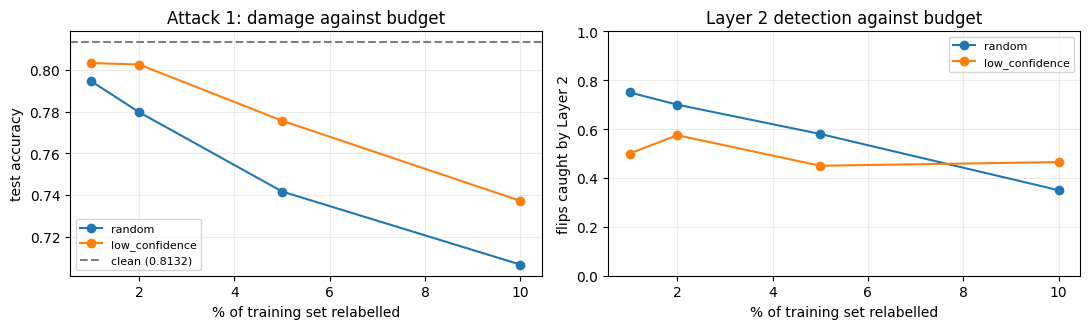

In [19]:
def make_flips(X, y, fraction, rule, seed):
    n = int(round(fraction * len(y)))
    if rule == "random":
        idx = np.random.default_rng(seed).choice(len(y), n, replace=False)
    else:
        sur = fit_head(X, y, seed)
        with torch.no_grad():
            p = torch.softmax(sur(X.to(DEVICE)), dim=1).cpu()
        top2 = p.topk(2, dim=1).values
        idx = np.argsort((top2[:, 0] - top2[:, 1]).numpy())[:n]
    flipped = y.clone()
    for i in idx:
        flipped[i] = (int(y[i]) + 1) % 10 
    return np.asarray(idx), flipped


flip_rows, flip_sets = [], {}
for rule in DEF_FLIP_RULES:
    for b in DEF_FLIP_BUDGETS:
        idx, yf = make_flips(X_train, y_train, b, rule, SEED)
        flip_sets[(rule, b)] = (idx, yf)
        scores = knn_disagreement(X_train, yf).numpy()
        mask = np.zeros(len(yf), bool); mask[idx] = True
        acc_att = accuracy(fit_head(X_train, yf, SEED), X_test, y_test)
        keep = scores < TAU
        acc_def = accuracy(fit_head(X_train[keep], yf[keep], SEED), X_test, y_test)
        flip_rows.append({"rule": rule, "budget": b,
                          "auc": float(roc_auc_score(mask, scores)),
                          "detection_rate": float((scores[mask] >= TAU).mean()),
                          "clean_rejection_rate": float((scores[~mask] >= TAU).mean()),
                          "accuracy_attacked": acc_att, "accuracy_defended": acc_def})
        print(f"{rule:>15s} budget={b:>5.0%}  acc {baseline_acc:.4f} -> {acc_att:.4f} -> {acc_def:.4f}  "
              f"AUC={flip_rows[-1]['auc']:.3f}  caught={flip_rows[-1]['detection_rate']:.1%}")


print()
for rule in DEF_FLIP_RULES:
    rows = sorted([r for r in flip_rows if r["rule"] == rule], key=lambda r: r["budget"])
    trend = rows[-1]["detection_rate"] - rows[0]["detection_rate"]
    print(f"{rule:>15s}: detection {rows[0]['detection_rate']:.1%} at {rows[0]['budget']:.0%} "
          f"-> {rows[-1]['detection_rate']:.1%} at {rows[-1]['budget']:.0%}  ({trend*100:+.1f}pp)")
print("\nWhere detection falls with budget: flipped records start becoming each other's")
print("nearest neighbours, so their neighbourhoods stop disagreeing with them.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for rule, colour in zip(DEF_FLIP_RULES, ["tab:blue", "tab:orange", "tab:purple"]):
    rows = sorted([r for r in flip_rows if r["rule"] == rule], key=lambda r: r["budget"])
    xs = [r["budget"] * 100 for r in rows]
    axes[0].plot(xs, [r["accuracy_attacked"] for r in rows], "o-", color=colour, label=rule)
    axes[1].plot(xs, [r["detection_rate"] for r in rows], "o-", color=colour, label=rule)
axes[0].axhline(baseline_acc, color="tab:gray", ls="--", label=f"clean ({baseline_acc:.4f})")
axes[0].set(xlabel="% of training set relabelled", ylabel="test accuracy",
            title="Attack 1: damage against budget")
axes[1].set(xlabel="% of training set relabelled", ylabel="flips caught by Layer 2",
            ylim=(0, 1), title="Layer 2 detection against budget")
for ax in axes: ax.grid(alpha=0.25); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots/flip_budget.png", dpi=150); plt.show()

In [20]:

idx_flip, y_flipped = flip_sets[(DEF_FLIP_RULES[0], DEF_FLIP_BUDGETS[-1])]
mismatch = (y_flipped != y_train).numpy()
print(f"trusted label: caught {mismatch.sum()}/{len(idx_flip)} flips, 0 false positives")
print(f"               caught 0/{NUM_TRIALS} poisons - the poison's label is correct")


def impact(X, y, candidates, seed=SEED, epochs=EPOCHS):
    """Leave-one-out held-out impact. Positive = removing the record HELPED."""
    base = float((predict(fit_head(X, y, seed, epochs), X_val) == y_val).float().mean())
    keep = torch.ones(len(y), dtype=torch.bool); out = {}
    for i in candidates:
        keep[i] = False
        out[int(i)] = float((predict(fit_head(X[keep], y[keep], seed, epochs), X_val) == y_val)
                            .float().mean()) - base
        keep[i] = True
    return base, out


rng_ctrl = np.random.default_rng(SEED)
ctrl_idx = rng_ctrl.choice(len(y_train), 8, replace=False)
_, d_ctrl = impact(X_train, y_train, list(ctrl_idx))
noise = np.array(list(d_ctrl.values()))
print(f"\nnoise floor (removing 8 random CLEAN records): "
      f"mean {noise.mean():+.4f}, sd {noise.std():.4f}, "
      f"range [{noise.min():+.4f}, {noise.max():+.4f}]")

Xp0 = torch.cat([X_train, poison_feats[0].unsqueeze(0)])
yp0 = torch.cat([y_train, torch.tensor([BASE_CLASS])])
_, d_poison = impact(Xp0, yp0, [len(yp0) - 1])
_, d_flips  = impact(X_train, y_flipped, list(idx_flip[:8]))
poison_impact = float(list(d_poison.values())[0])
flip_impact   = float(np.mean(list(d_flips.values())))

threshold = noise.mean() + 2 * noise.std()
print(f"\nimpact check (positive = removing the record helped):")
print(f"  flipped record  {flip_impact:+.4f}   "
      f"{'outside' if flip_impact > threshold else 'INSIDE'} the noise floor")
print(f"  clean-label poison {poison_impact:+.4f}   "
      f"{'outside' if poison_impact > threshold else 'INSIDE'} the noise floor")
print("\nA record whose impact sits inside the noise floor is invisible to this check.")
print("The poison flips its target while leaving no measurable trace in held-out accuracy,")
print("which is exactly why Layer 2 is needed.")

trusted label: caught 200/200 flips, 0 false positives
               caught 0/50 poisons - the poison's label is correct

noise floor (removing 8 random CLEAN records): mean -0.0021, sd 0.0015, range [-0.0040, +0.0000]

impact check (positive = removing the record helped):
  flipped record  +0.0022   outside the noise floor
  clean-label poison -0.0010   INSIDE the noise floor

A record whose impact sits inside the noise floor is invisible to this check.
The poison flips its target while leaving no measurable trace in held-out accuracy,
which is exactly why Layer 2 is needed.


In [21]:

defended = []
for k in range(DEFENSE_EVAL_TRIALS):
    Xp = torch.cat([X_train, poison_feats[k].unsqueeze(0)])
    yp = torch.cat([y_train, torch.tensor([BASE_CLASS])])
    keep = knn_disagreement(Xp, yp) < TAU
    seed = SEED + k

    h_def = fit_head(Xp[keep], yp[keep], seed)
    after, _ = predict_one(h_def, target_feats[k])
    row = results[k]
    defended.append({
        "trial": k,
        "poison_removed": bool(not keep[-1]),
        "clean_dropped": int((~keep[:-1]).sum()),
        "success_before": row["success"],
        "success_after": bool(row["clean_correct"] and after == BASE_CLASS),
        "accuracy_before": row["poisoned_accuracy"],
        "accuracy_after": accuracy(h_def, X_test, y_test),
    })

m = lambda k: float(np.mean([r[k] for r in defended]))
defense_summary = {
    "k": DEFENSE_K, "threshold": TAU, "auc": float(auc), "sweep": sweep,
    "poison_removal_rate": m("poison_removed"),
    "success_before": m("success_before"), "success_after": m("success_after"),
    "accuracy_before": m("accuracy_before"), "accuracy_after": m("accuracy_after"),
    "mean_clean_dropped": m("clean_dropped"),
    "clean_rejection_rate": m("clean_dropped") / len(y_train),
    "layer1_poison_impact": poison_impact, "layer1_flip_impact": flip_impact,
    "flip_contrast": flip_rows,
}
print(f"poison removed    {defense_summary['poison_removal_rate']:.1%} of trials")
print(f"attack success    {defense_summary['success_before']:.1%} -> {defense_summary['success_after']:.1%}")
print(f"test accuracy     {defense_summary['accuracy_before']:.4f} -> {defense_summary['accuracy_after']:.4f}")
print(f"clean discarded   {defense_summary['mean_clean_dropped']:.0f}/{len(y_train)} "
      f"({defense_summary['clean_rejection_rate']:.1%})")

json.dump({"defense": defense_summary, "trials": defended},
          open(OUTPUT_DIR / "defense_results.json", "w"), indent=2)

poison removed    98.0% of trials
attack success    86.0% -> 2.0%
test accuracy     0.8111 -> 0.8179
clean discarded   54/2000 (2.7%)


## Summary table

In [22]:

flip_row = [r for r in flip_rows if r["budget"] == DEF_FLIP_BUDGETS[-1]][-1]
rows = [
    ("", f"label flip ({flip_row['budget']:.0%}, {flip_row['rule']})", "clean-label poison (1 record)"),
    ("what changes", "labels on existing records", "one added image, label correct"),
    ("clean accuracy", f"{baseline_acc:.4f}", f"{baseline_acc:.4f}"),
    ("attacked accuracy", f"{flip_row['accuracy_attacked']:.4f}", f"{defense_summary['accuracy_before']:.4f}"),
    ("accuracy change", f"{flip_row['accuracy_attacked']-baseline_acc:+.4f}",
     f"{defense_summary['accuracy_before']-baseline_acc:+.4f}"),
    ("targeted success", "n/a (indiscriminate)", f"{defense_summary['success_before']:.1%}"),
    ("", "", ""),
    ("Layer 1 trusted label", "catches 100%", "catches 0% - label is correct"),
    ("Layer 1 impact check", f"{flip_impact:+.4f} on removal", f"{poison_impact:+.4f} on removal"),
    ("Layer 2 neighbour check", f"catches {flip_row['detection_rate']:.0%} (AUC {flip_row['auc']:.3f})",
     f"catches {op['detection_rate']:.0%} (AUC {auc:.3f})"),
    ("clean records discarded", f"{flip_row['clean_rejection_rate']:.1%}",
     f"{defense_summary['clean_rejection_rate']:.1%}"),
    ("success after defense", "n/a", f"{defense_summary['success_after']:.1%}"),
]
w = [max(len(str(r[c])) for r in rows) for c in range(3)]
print("=" * (sum(w) + 8))
for i, r in enumerate(rows):
    print(f"  {str(r[0]):<{w[0]}}  {str(r[1]):<{w[1]}}  {str(r[2]):<{w[2]}}")
    if i == 0: print("  " + "-" * (sum(w) + 4))
print("=" * (sum(w) + 8))

                           label flip (10%, low_confidence)  clean-label poison (1 record) 
  -----------------------------------------------------------------------------------------
  what changes             labels on existing records        one added image, label correct
  clean accuracy           0.8132                            0.8132                        
  attacked accuracy        0.7371                            0.8111                        
  accuracy change          -0.0761                           -0.0021                       
  targeted success         n/a (indiscriminate)              86.0%                         
                                                                                           
  Layer 1 trusted label    catches 100%                      catches 0% - label is correct 
  Layer 1 impact check     +0.0022 on removal                -0.0010 on removal            
  Layer 2 neighbour check  catches 46% (AUC 0.953)           catches 98% (AUC 0.

In [23]:

demo_trial = next((r["trial"] for r in results if r["success"]), 0)
torch.save({
    "clean_head":    fit_head(X_train, y_train, SEED + demo_trial).state_dict(),
    "poisoned_head": fit_head(torch.cat([X_train, poison_feats[demo_trial].unsqueeze(0)]),
                              torch.cat([y_train, torch.tensor([BASE_CLASS])]),
                              SEED + demo_trial).state_dict(),
    "poison_image":  poisons[demo_trial].cpu(),
    "base_image":    base0["image"],
    "target_image":  targets[demo_trial]["image"],
    "other_targets": torch.stack([t["image"] for t in targets[:8]]),
    "class_names":   class_names,
    "config":        {"seed": SEED, "target_class": TARGET_CLASS, "base_class": BASE_CLASS,
                      "input_size": 224, "weights": "ResNet18_Weights.IMAGENET1K_V1"},
}, OUTPUT_DIR / "demo.pt")
print("saved demo.pt")

saved demo.pt
